# Setup
## About this notebook
* This is the third notebook. It is focused on looking at ecoinvent through the lens of networks and is largely the same as the second notebook, just updated to use ecoinvent 3.11
* Author: Fitz Koch

## Import and Git


In [1]:
import bw2io as bi
import bw2data as bd
import bw2calc as bc
import git

import networkx as nx
from networkx.algorithms import bipartite
import random
from collections import defaultdict
from matplotlib import pyplot as plt 
import json
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches


In [2]:
def get_git_root():
    repo = git.Repo(search_parent_directories=True)
    return repo.git.rev_parse("--show-toplevel")
root = get_git_root()

In [3]:
for m in bd.methods:
    print(m)


## Brightway setup

In [4]:
bd.projects.set_current('SEE_LAB') 
eidb = bd.Database("ecoinvent-3.11-cutoff")

# Exploration

## Brightway structure

In [5]:
random_act = eidb.random()
random_act.as_dict()

{'comment': "This is a market activity. Each market represents the consumption mix of a product in a given geography, connecting suppliers with consumers of the same product in the same geographical area. Markets group the producers and also the imports of the product (if relevant) within the same geographical area. They also account for transport to the consumer and for the losses during that process, when relevant.\nThis is the market for  'haying, by rotary tedder', in the Global geography.\nThis market contains no transport or losses, as they are irrelevant for the delivered product.\nThis is delivering the service of 'haying, by rotary tedder' on an area of one hectare. It includes the use of diesel powered mobile infrastructure (tractors, machinery). Diesel combustion linearly affects direct emissions. Hence, a user can model the right amount of this service by using information on diesel consumption. For example: If within the user's model diesel consumption is 30 kg/ha while in

In [6]:
random_exc = [exc for exc in random_act.exchanges()][0].as_dict()
random_exc

{'flow': '68850e7f-0daf-4744-a87d-146555861f30',
 'type': 'production',
 'name': 'haying, by rotary tedder',
 'classifications': {'CPC': ['86119: Other support services to crop production']},
 'production volume': 3354250891.71313,
 'properties': {'carbon allocation': {'amount': 0.0, 'unit': 'kg'},
  'carbon content': {'amount': 0.0, 'unit': 'dimensionless'},
  'price': {'amount': 2.863053533203498,
   'comment': 'Calculated based on inputs: The price of the product has been calculated as a sum of the values of the material and energy inputs for this product. This value is therefore a rough estimation. It may underestimate the real price since there are additional expenses when producing any product. These expences can include for example labour costs, treatment of waste materials and profit for the producer. Please consider carefully whether this level of data quality is acceptable for your application.',
   'unit': 'EUR2005'}},
 'activity': '0b2de79a-4187-5b39-835d-a39b09debc24',
 'u

As we can see, each exchange stores an "input" and "ouput" var (when treated as a dict). 

Our goal is to use this exchange as an edge between the two nodes.

So first we'll get make just a node graph of all the processes (and maybe a bipartite network between biosphere and technosphere?)

And then we'll iterate through all the edges and join them.


**Note**: from the initial import as well as manually iterating (deleted), we know that t process count is 21238, while the exchange count is 674593 (for ecoinvent 3.9.1 -- but maybe we should upgrade to 3.11)



## Case study: make a graph from the database

In [7]:
G = nx.DiGraph()

## attach the nodes
for act in eidb:
    G.add_node(act['code'], **act)

G.number_of_nodes()

25412

In [8]:
random_node = random.choice(list(G.nodes))
G.nodes[random_node]

{'comment': 'This dataset represents the service of the spreading of sludge from pulp and paper production on agricultural fields. The sludge is a mix of sludge from primary and secondary wastewater treatment and from a deinking process. The reference flow is one kg of pulp and paper sludge (wet mass) loaded from storage unit at the farm, transported to farmlands and spread as organic fertilisers with solid manure spreader. It is assumed the sludge is applied to maize cropland (25%), soybeans (35%) and cultivated grassland (40%). The dataset is heavily parameterized and could be used as a template for sludges with other compositions insofar as sludge composition is changed in the reference flow exchange properties and the plausibility of values for context-specific parameters (e.g. ammonia emissions) are checked.\nIncluded activities start:  From sludge loading into solid manure spreader with hydraulic loader at farm.\nIncluded activities end:  This activity ends with pulp and paper sl

We can also look at this right from brightway

In [9]:
random_node = eidb.random()
print(random_node)
print(json.dumps(
    random_node.as_dict(), indent=4))

'heat and power co-generation, biogas, gas engine' (kilowatt hour, US-RFC, None)
{
    "comment": "This dataset represents the production of electricity and heat from a biogas mix from different sources (biowaste, sewage sludge) when burning it in a cogeneration unit with gas engine. It is intended to represent the production of grid-connected electricity with biogas. The main product is then considered to be electricity at high voltage, while heat is produced as a co-product. The cogeneration unit has a capacity of 160 kWel; the degrees of efficiency are as follows: electricity: 0.37 and heat: 0.53. A mix of biogas is treated in this dataset with an average lower heating value of 22.73 MJ/Nm3.\nIncluded activities start:  From the cogeneration unit ready to treat biogas and from the biogas entry at the power plant.\nIncluded activities end:  This activity ends with the production of electricity high voltage, corresponding to the treatment of 1m3 of biogas in a cogeneration unit. \n\nT

In [10]:
def print_node(item):
    print(json.dumps(
    item.as_dict(), indent=4))

def print_dict(dict):
    print(json.dumps(dict, indent=4))

In [11]:
random_exc = [exc for exc in eidb.random().exchanges()][0]
print(random_exc)
print(json.dumps(
    random_exc.as_dict(), indent=4))

Exchange: 1.0 kilogram 'electrolysis of magnesium chloride, from hafnium sponge production' (kilogram, RoW, None) to 'electrolysis of magnesium chloride, from hafnium sponge production' (kilogram, RoW, None)>
{
    "flow": "de0844f7-1fab-44b5-8d77-2a608f26fcc0",
    "type": "production",
    "name": "magnesium, for reuse in hafnium sponge production",
    "classifications": {
        "CPC": [
            "41601: Tungsten, molybdenum, tantalum, magnesium, cobalt, cadmium, titanium, zirconium, beryllium, gallium, hafnium, [\u2026]"
        ]
    },
    "production volume": 3333.941948249998,
    "properties": {
        "allocation factor": {
            "amount": 0.8983061969905153,
            "unit": "dimensionless"
        },
        "carbon allocation": {
            "amount": 0.0,
            "unit": "kg"
        },
        "carbon content": {
            "amount": 0.0,
            "unit": "dimensionless"
        },
        "carbon content, fossil": {
            "amount": 0.0,
    

Note that we have a choice of edge weight here. Possible options include:

* Production Volume -- how much is produced per yearso to speak. So maybe that means 482279000.0 kg of peanuts per annual year. 
* Any of the properties eg:
    * carbon acollocation 
    * carbon content
    * price 
    * amount -- the actual specific quantity. this is what is evaluated by impact assessment calculations.

But none of them *really* make sense to me to use. I suspect in the end we'll probably end up using different ones for different analysis for different types of processes.

I think probably the most sensible "standard," though, is amount. 



Either way, now we link the exchanges.

In [12]:
## Build the exchanges
for act in eidb:
    for exc in act.exchanges():
        input_node = exc["input"][1]
        output_node = exc["output"][1]
        weight = exc.get('Production Volume')
        carbon_content = exc.get('properties', {}).get('carbon content', {}).get('amount', 0)
        carbon_allocation = exc.get('properties', {}).get('carbon allocation', {}).get('amount', 1)
        
        # Calculate carbon flow for the edge
        carbon_flow = carbon_content * carbon_allocation
        # Add edge to the graph
        G.add_edge(input_node, output_node, carbon_flow=carbon_flow, weight=weight, **exc)



Now we can start looking at the nodes and edges in a more systematic way

In [13]:
out_edges = G.out_edges(random_node['code'], data=True)
for u, v, edge_data in out_edges:
    # Print edge info with formatted data
    edge_data_str = json.dumps(edge_data, indent=4)  # Pretty-print the edge data
    print(f"Edge from {u} to {v} with data:\n{edge_data_str}")
    print(f"\tHas location: {G.nodes[u].get('location', 'No location attribute')} \n")


Edge from a2f9fb72893c910728fe7d211e588edc to 5fb6bc3ae3f27e29d18952c5bb5833c0 with data:
{
    "carbon_flow": 0.0,
    "weight": null,
    "flow": "66c93e71-f32b-4591-901c-55395db5c132",
    "type": "technosphere",
    "name": "electricity, high voltage",
    "classifications": {
        "CPC": [
            "17100: Electrical energy"
        ]
    },
    "production volume": 0.0,
    "properties": {
        "allocation factor": {
            "amount": 0.804471860429623,
            "unit": "dimensionless"
        },
        "carbon allocation": {
            "amount": 0.0,
            "unit": "kg"
        },
        "carbon content": {
            "amount": 0.0,
            "unit": "dimensionless"
        },
        "exergy": {
            "amount": 3.6,
            "unit": "MJ"
        },
        "heating value, net": {
            "amount": 0.0,
            "unit": "MJ"
        },
        "price": {
            "amount": 0.0977,
            "unit": "EUR2005"
        },
        "tru

Interestingly, we get one MORE consuming (outgoing) edge than ecoquery suggests. One for the *market* for the low pressure gas and one that just goes back to itself. 


I'm not totally sure of this, but I think we can see [Brightway Inventory Documentation](https://docs.brightway.dev/en/latest/content/overview/inventory.html) for why:

"However, many databases we build on do not make a clean distinction between products and processes. In this case, to accurately reflect the data schema of the imported data, and to simplify graph traversal, we can create a chimaera node which is both process and reference product. In this case, a process produces itself, as it is both a process and a product. Because the product and process are bound together, these processes can only have one functional edge. These chimaera nodes have the data of both the process and the product, and the information of the (reference) product is given in Brightway by:

unit: The unit of the product produced

reference product: The name of the product produced"

This doesn't quite make sense, though, because we the text above has no reference product field.


Anyway, now we look at the incoming edges


In [14]:
incoming_edges = G.in_edges(random_node['code'], data=True)

for u, v, edge_data in incoming_edges:
    edge_data_str = json.dumps(edge_data, indent=4)  # Pretty-print the edge data
    print(f"Edge from {u} to {v} with data:\n{edge_data_str}")
    # print(f"Edge from {u} to {v} with data: {edge_data} \n\t has {G.nodes[u]['location']} as location")

print("\n")

Edge from a2f9fb72893c910728fe7d211e588edc to a2f9fb72893c910728fe7d211e588edc with data:
{
    "carbon_flow": 0.0,
    "weight": null,
    "flow": "66c93e71-f32b-4591-901c-55395db5c132",
    "type": "production",
    "name": "electricity, high voltage",
    "classifications": {
        "CPC": [
            "17100: Electrical energy"
        ]
    },
    "production volume": 2842690461.322107,
    "properties": {
        "allocation factor": {
            "amount": 0.804471860429623,
            "unit": "dimensionless"
        },
        "carbon allocation": {
            "amount": 0.0,
            "unit": "kg"
        },
        "carbon content": {
            "amount": 0.0,
            "unit": "dimensionless"
        },
        "exergy": {
            "amount": 3.6,
            "comment": "allocation factor for electricity (=1) vs. heat, where heat is calculated as the termodynamic mean temperature Tm = (Tfeed-Treturn)/ln(Tfeed/Treturn), relative to the application temperature (Tu, t

In [15]:
def print_inc_edges(node):
    incoming_edges = G.in_edges(node, data=True)
    for u, v, edge_data in incoming_edges:
        edge_data_str = json.dumps(edge_data, indent=4)  # Pretty-print the edge data
        print(f"Edge from {u} to {v} with data:\n{edge_data_str}")
        # print(f"Edge from {u} to {v} with data: {edge_data} \n\t has {G.nodes[u]['location']} as location")

    print("\n")

Let's just iterate by following the first incoming edge for a while and see where we go.

In [16]:
def follow_first_edges(current_node, steps=50):
    # Start with the random node
    count = 0

    while count < steps:
        incoming_edges = list(G.in_edges(current_node, data=True))

        if not incoming_edges: 
            print(f"No more incoming edges for node {current_node}.")
            break

        
        try: u, v, edge_data = incoming_edges[0]
        except: 
            print("ran out of edges")
            break
        if u == v: ## often the first edge is self-referential (see above markdown note)
            try: u, v, edge_data = incoming_edges[1]
            except: 
                print("ran out of edges")
                break

        name1 = G.nodes[u].get('name')
        name2 = G.nodes[v].get('name')
        
        print(f"Edge from <{u}:{name1}> TO <{v}{name2}>")
        
        # Move to the previous node (incoming edge's source)
        current_node = u
        count += 1

    print("\n")

follow_first_edges(current_node = random_node['code'])


Edge from <c75873783c29a28264ee43580f4ee60d:market for biogas> TO <a2f9fb72893c910728fe7d211e588edcheat and power co-generation, biogas, gas engine>
Edge from <b04e36202ae277e2d7cbd27737d9440c:treatment of used vegetable cooking oil by anaerobic digestion> TO <c75873783c29a28264ee43580f4ee60dmarket for biogas>
Edge from <d01d4a2b9c23f30e9458df9028cc7f45:market for anaerobic digestion plant, agriculture, with methane recovery> TO <b04e36202ae277e2d7cbd27737d9440ctreatment of used vegetable cooking oil by anaerobic digestion>
Edge from <e8a3aeba8b3281d4a77063f4e2d860b3:anaerobic digestion plant construction, agriculture, with methane recovery> TO <d01d4a2b9c23f30e9458df9028cc7f45market for anaerobic digestion plant, agriculture, with methane recovery>
Edge from <87bb4787ebfb063cbef55347922df876:market for concrete, normal strength> TO <e8a3aeba8b3281d4a77063f4e2d860b3anaerobic digestion plant construction, agriculture, with methane recovery>
Edge from <20875a0217149c1e4083cbf58689c46e:co

In [17]:
follow_first_edges(current_node=random.choice(list(G.nodes)))

No more incoming edges for node d12347c3-71b1-5900-9386-39df6d0004dc.




Okay, this gives us a better sense of how the edges and nodes are operating, particularly the split between production and market. We're not choosing intelligently so its not the most revealing.

Note that there **do** seem to be motifs, or cyclical sub-networks, nested in here. If we just follow the first edge we **can** trapped in a cycle.

One thing we can expand to is following the heaviest weight.

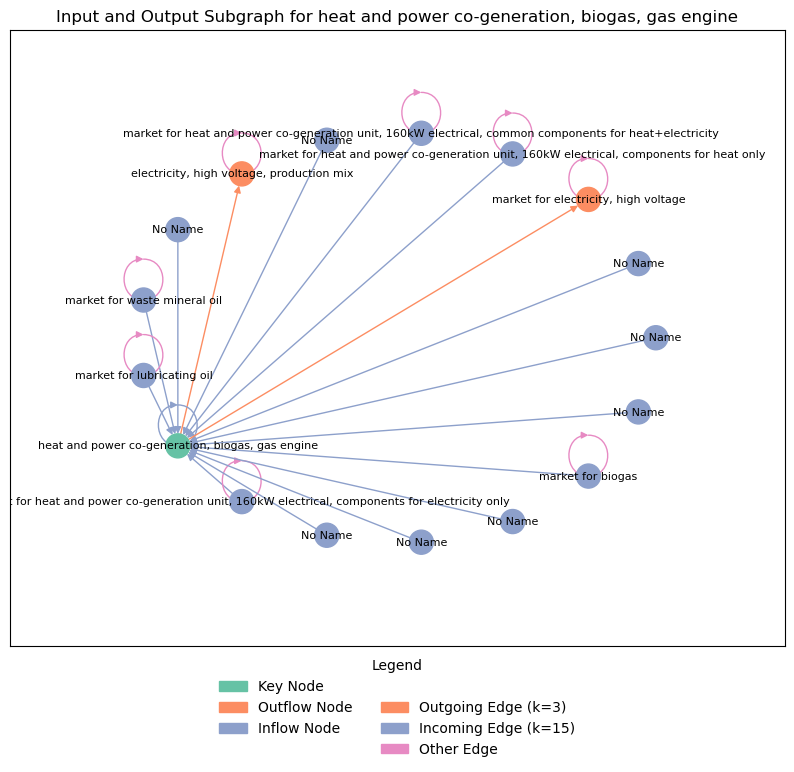

'a2f9fb72893c910728fe7d211e588edc'

In [18]:
def subgraph_node(highlight_node, path=None, labels=True, palette=None):

    ## Set up color scheme
    if not palette:
        palette = sns.color_palette("Set2", 4)


    outflow = set(G.successors(highlight_node))
    inflow = set(G.predecessors(highlight_node))
    sub_nodes = {highlight_node} | outflow | inflow
    subgraph = G.subgraph(sub_nodes)

    edges_to_draw = [(u, v) for u, v in subgraph.edges()]
    edge_weights = [subgraph[u][v].get('weight', 1) for u, v in edges_to_draw]

    node_colors = [
        palette[0] if n == highlight_node else
        palette[1] if n in outflow else
        palette[2] if n in inflow else
        palette[3] 
        for n in subgraph.nodes()
    ]

    edge_colors = [
        palette[2] if v == highlight_node else
        palette[1] if u == highlight_node else
        palette[3]
        for u, v in edges_to_draw
    ]

    labels = {
        n: data.get('name', 'No Name')
        for n, data in subgraph.nodes(data=True)
    }

    # Only layout that is working for some unclear reason
    pos = nx.circular_layout(subgraph)

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors)
    nx.draw_networkx_edges(subgraph, pos, edgelist=edges_to_draw, width=edge_weights, edge_color=edge_colors)
    if labels:
        nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=8)
        plt.xlim(-1.5, 1.5)  
        plt.ylim(-1.5, 1.5)  

    # Combined legend
    node_legend = [
        mpatches.Patch(color=palette[0], label='Key Node'),
        mpatches.Patch(color=palette[1], label='Outflow Node'),
        mpatches.Patch(color=palette[2], label='Inflow Node'),
        mpatches.Patch(color='none', label=''),  # Empty patch to fill out the column

        # mpatches.Patch(color=palette[3], label='Other Node')
    ]

    edge_legend = [
        mpatches.Patch(color='none', label=''),  # Empty patch to fill out the column
        mpatches.Patch(color=palette[1], label=f'Outgoing Edge (k={G.out_degree(highlight_node)})'),
        mpatches.Patch(color=palette[2], label=f'Incoming Edge (k={G.in_degree(highlight_node)})'),
        mpatches.Patch(color=palette[3], label='Other Edge')
    ]

    plt.legend(handles=node_legend + edge_legend, title="Legend", 
               loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
    
    plt.title(f"Input and Output Subgraph for {G.nodes[highlight_node]['name']}")

    if path:
        plt.savefig(path)

    
    plt.show()
    return highlight_node

subgraph_node(highlight_node=random_node['code'])


So whats with all these "no name" nodes? First, lets check if they are actually in brightway... 

In [19]:
highlight_node = random_node['code']
outflow = set(G.successors(highlight_node))
inflow = set(G.predecessors(highlight_node))
sub_nodes = {highlight_node} | outflow | inflow
subgraph = G.subgraph(sub_nodes)
for node, data in subgraph.nodes(data=True):
    try: print(node, data, eidb.get(node))
    except: print(f"{node}, {data} not in db")

57bdb443-d4a6-423d-8024-959b8261d02e, {} not in db
afd6d670-bbb0-4625-9730-04088a5b035e, {} not in db
74a96c32cba3d0960d98dbd267dfc424 {'comment': "This is a market activity. Each market represents the consumption mix of a product in a given geography, connecting suppliers with consumers of the same product in the same geographical area. Markets group the producers and also the imports of the product (if relevant) within the same geographical area. They also account for transport to the consumer and for the losses during that process, when relevant.\nThis dataset describes the electricity available on the high voltage level in ReliabilityFirst Corporation. This is done by showing the transmission of 1kWh electricity at high voltage.\nThe shares of electricity technologies on this market are valid for the year 2022. They have been calculated by the data provider and don't correspond with the production volumes entered in the undefined datasets of the different electricity supplying tech

So these one's that are appearing as "not named" are not in the technosphere... why? Lets look more closely at one

In [20]:
print_inc_edges(highlight_node)

Edge from a2f9fb72893c910728fe7d211e588edc to a2f9fb72893c910728fe7d211e588edc with data:
{
    "carbon_flow": 0.0,
    "weight": null,
    "flow": "66c93e71-f32b-4591-901c-55395db5c132",
    "type": "production",
    "name": "electricity, high voltage",
    "classifications": {
        "CPC": [
            "17100: Electrical energy"
        ]
    },
    "production volume": 2842690461.322107,
    "properties": {
        "allocation factor": {
            "amount": 0.804471860429623,
            "unit": "dimensionless"
        },
        "carbon allocation": {
            "amount": 0.0,
            "unit": "kg"
        },
        "carbon content": {
            "amount": 0.0,
            "unit": "dimensionless"
        },
        "exergy": {
            "amount": 3.6,
            "comment": "allocation factor for electricity (=1) vs. heat, where heat is calculated as the termodynamic mean temperature Tm = (Tfeed-Treturn)/ln(Tfeed/Treturn), relative to the application temperature (Tu, t

## Adding Biosphere as Multipartite graphs

Ah! When we ctrl-f for one of the naughty nodes it becomes obvious why it didn't show -- these are edges that originate in **biosphere** nodes.

So now we can recreate the network as a multipartite graph. We don't use the built in bipartite model because networkx doesn't allow for links between the same set and the technosphere definitely has to link to itself.

In [21]:
ei_biosphere = bd.Database("ecoinvent-3.11-biosphere")


In [22]:
random_bio = ei_biosphere.random()
print(json.dumps(random_bio.as_dict(), indent=4))

{
    "categories": [
        "air",
        "low population density, long-term"
    ],
    "code": "34de4196-871a-4db8-a182-589ab780a935",
    "CAS number": "000075-43-4",
    "synonyms": [
        "dichloro(fluoro)methane",
        "Dichlormonofluormethan",
        "dichlorofluoromethane",
        "Methane, dichlorofluoro-",
        "HCFC-21"
    ],
    "name": "Dichlorofluoromethane",
    "database": "ecoinvent-3.11-biosphere",
    "unit": "kilogram",
    "type": "emission",
    "id": 29364
}


In [23]:
G = nx.DiGraph()

## attach the nodes
for act in eidb:
    G.add_node(act['code'], node_type='Technosphere', **act)
    for exc in act.exchanges():
        input_node = exc["input"][1]
        output_node = exc["output"][1]
        weight = exc.get('Production Volume')
        carbon_content = exc.get('properties', {}).get('carbon content', {}).get('amount', 0)
        carbon_allocation = exc.get('properties', {}).get('carbon allocation', {}).get('amount', 1)
        
        # Calculate carbon flow for the edge
        carbon_flow = carbon_content * carbon_allocation
        # Add edge to the graph
        G.add_edge(input_node, output_node, carbon_flow=carbon_flow, weight=weight, **exc)

for act in ei_biosphere:
    G.add_node(act['code'], node_type='Biosphere', **act)
    ## my understanding is that biosphere nodes don''t have exchanges so we can skip that

G.number_of_nodes()

35207

Now when we try to graph these we get all the names included.

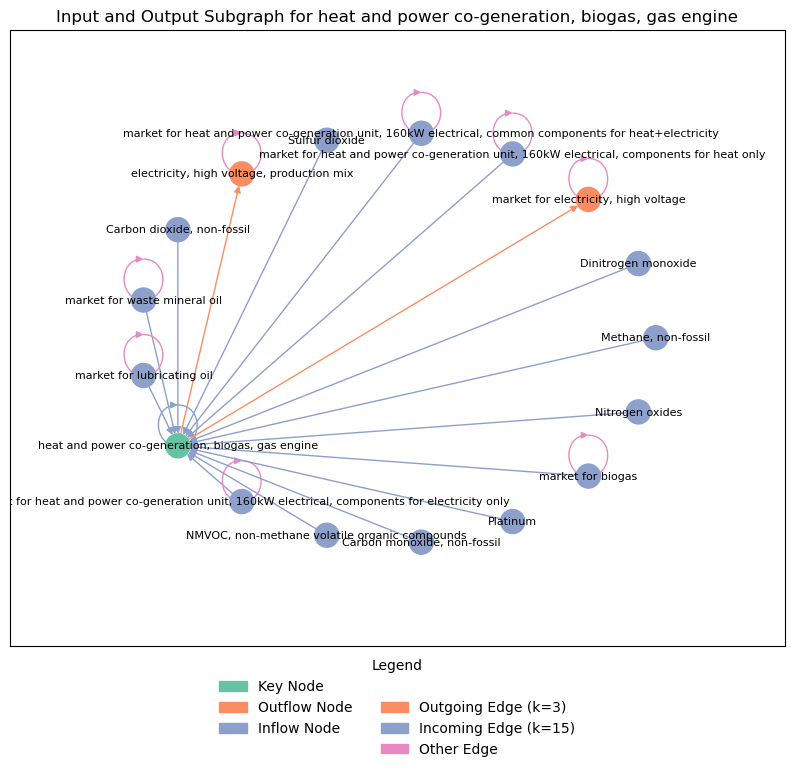

'a2f9fb72893c910728fe7d211e588edc'

In [24]:
subgraph_node(highlight_node=random_node['code'])

And for a newly generated node:

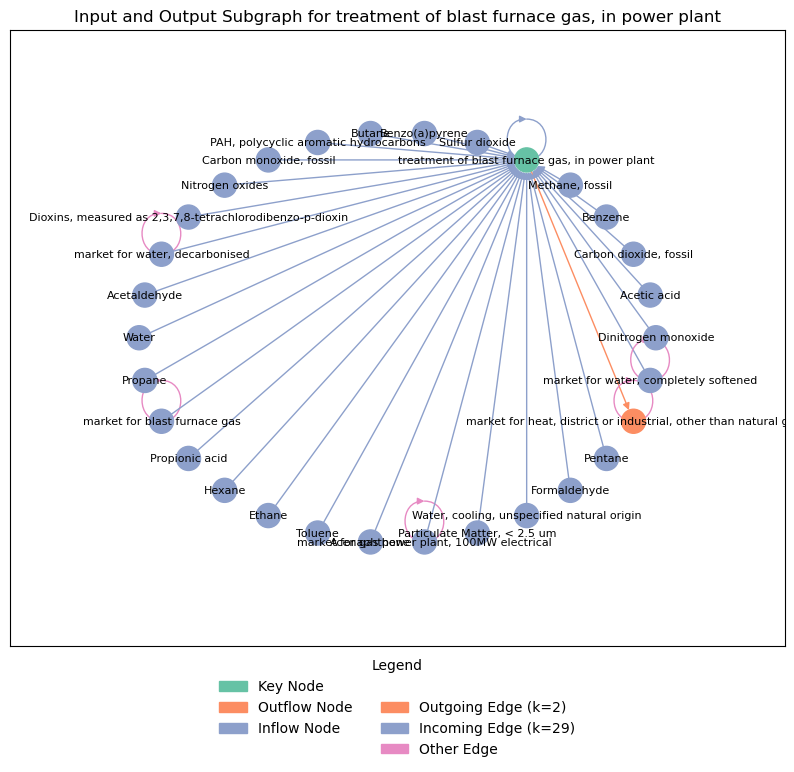

'93c345a103403a012d7bf5c4a25f4722'

In [25]:
technosphere_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'Technosphere']

# Select a random technosphere node
new_node = random.choice(technosphere_nodes)
subgraph_node(new_node)


In [26]:
# def find_node_in_bw(id):
#     try:
#         b = eidb.get(id)
#         # print(b)
#         # b = b.as_dict()
#         # print("technosphere", json.dumps(b, indent=4))
#     except:
#         try: 
#                 b = ei_biosphere.get(id)
#                 # print(b)
#                 # b = b.as_dict()
#                 # print("biosphere", json.dumps(b, indent=4))
#         except:
#             print(id)
#             raise ValueError("Not Found")
#     for exc in b.exchanges():
#          print(exc)
    
# eidb = bd.Database("ecoinvent-3.9.1-cutoff")
# ei_biosphere = bd.Database("ecoinvent-3.9.1-biosphere")



# for line in data:
#      line = str(line)
#      line = line.strip()
#      find_node_in_bw(line)

In [27]:
# path = "0f70e720-127e-44dc-bb85-438158235ab6"

# a = ei_biosphere.get(path)
# print(json.dumps(a.as_dict() ,indent=4))
# for exc in a.exchanges():
#     print(exc)

## Miscellaneous networkx stuff

See how the types work -- note that all the technosphere nodes are processes, while the biosphere nodes are more subdivided. We have emission, natural resource, inventory indicator, and economic nodes.

In [28]:
# for node, data in G.nodes()
types = defaultdict(int)

for node, data in G.nodes(data=True):
    kind = data.get('node_type') 
    val = data.get("type")
    types[kind + ': ' + val] += 1

print_dict(types)


{
    "Technosphere: process": 25412,
    "Biosphere: emission": 9428,
    "Biosphere: natural resource": 347,
    "Biosphere: inventory indicator": 15,
    "Biosphere: economic": 5
}


## clustering

First, get a sense of the edge weight distribution. Recall from above that edge weight could be defined as:

* production volume
* any of the values in the carbon dict:
    * allocation*carbon amount (carbon flow)

Min Weight: 0.0
Max Weight: 40601489.5
Average Weight: 1845.1167814874789


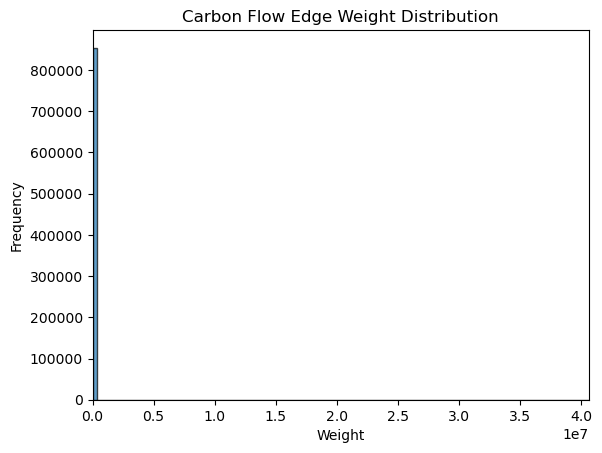

In [29]:
weights = [data['carbon_flow'] for _, _, data in G.edges(data=True)]

# Print basic statistics
# print("agh")
# print("Edge Weights:", weights)
print("Min Weight:", min(weights))
print("Max Weight:", max(weights))
avg_weight =  sum(weights) / len(weights)
print("Average Weight:", avg_weight)


# Because there are some big big outliers, we can plot just to a low value.
# We also strip out 0-1 (minimal)
plt.hist(weights, bins=100, edgecolor='black', alpha=0.7)
plt.title("Carbon Flow Edge Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.xlim(0, max(weights))
plt.show()

Min Weight: 1.0000000000000007
Max Weight: 244.03600000000006
Average Weight: 92.23832089420513


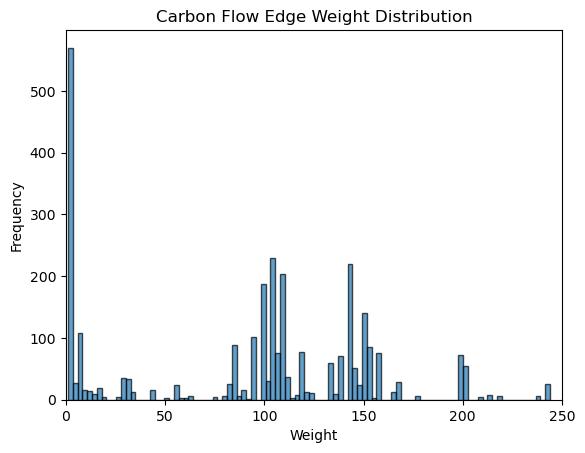

In [30]:
weights = [data['carbon_flow'] for _, _, data in G.edges(data=True)]

# Print basic statistics
# print("agh")
# print("Edge Weights:", weights)
filtered_weights = [w for w in weights if 1 < w <= 250]
print("Min Weight:", min(filtered_weights))
print("Max Weight:", max(filtered_weights))
avg_weight =  sum(filtered_weights) / len(filtered_weights)
print("Average Weight:", avg_weight)


# Because there are some big big outliers, we can plot just to a low value.
# We also strip out 0-1 (minimal)
plt.hist(filtered_weights, bins=100, edgecolor='black', alpha=0.7)
plt.title("Carbon Flow Edge Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.xlim(0, 250)
plt.show()

Min Weight: 9.27474132871974e-103
Max Weight: 1.0
Average Weight: 0.3653083857758664


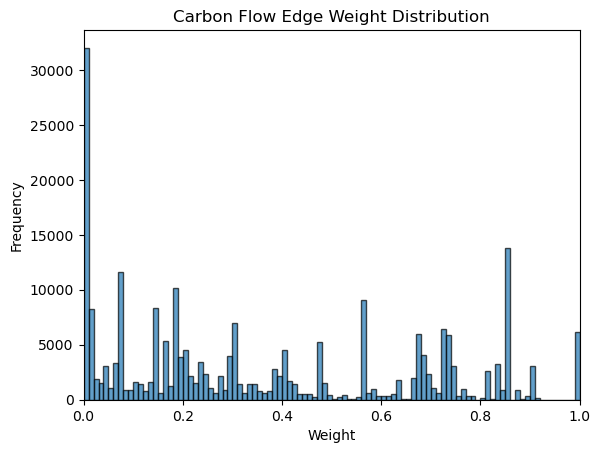

In [31]:
weights = [data['carbon_flow'] for _, _, data in G.edges(data=True)]

# Print basic statistics
# print("agh")
# print("Edge Weights:", weights)
filtered_weights = [w for w in weights if 0 < w <= 1]

print("Min Weight:", min(filtered_weights))
print("Max Weight:", max(filtered_weights))
avg_weight =  sum(filtered_weights) / len(filtered_weights)
print("Average Weight:", avg_weight)


# Because there are some big big outliers, we can plot just to a low value.
# We also strip out 0-1 (minimal)
filtered_weights = [w for w in weights if 0 < w <= 1]
plt.hist(filtered_weights, bins=100, edgecolor='black', alpha=0.7)
plt.title("Carbon Flow Edge Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.show()

## Degree Characterization

In [32]:
indegree_dict = defaultdict(int)
outdegree_dict = defaultdict(int)


for node in G.nodes():
    val = G.in_degree[node]
    indegree_dict[val] += 1
    val = G.out_degree[node]
    outdegree_dict[val] += 1

indegree_frame = pd.DataFrame(list(indegree_dict.items()), columns=['Degree', 'Count'])
indegree_frame.sort_values(by='Count', ascending=False).head(10)

,Degree,Count
21,0,9795
3,2,2578
1,3,2228
7,5,1712
6,6,1463
0,1,1363
18,4,1227
16,7,1110
10,8,623
5,10,613


In [33]:

outdegree_frame = pd.DataFrame(list(outdegree_dict.items()), columns=['Degree', 'Count'])
outdegree_frame.sort_values(by='Count', ascending=False).head(10)

,Degree,Count
1,2,14670
661,0,6557
0,1,3056
13,3,2191
541,4,1034
600,5,547
515,6,384
29,7,262
640,9,217
572,10,196


In [34]:
def counts_to_rank(counts):
    """
    Given a dataframe of raw counts, return a dataframe with the
    rank.
    """
    df = counts.copy()
    df = df[df['Count'] > 0]
    df['Rank'] = df['Count'].rank(ascending=False)
    return df


In [35]:
indegree_rank = counts_to_rank(indegree_frame)
indegree_rank.sort_values(by='Count', ascending=False).head(20)



,Degree,Count,Rank
21,0,9795,1.0
3,2,2578,2.0
1,3,2228,3.0
7,5,1712,4.0
6,6,1463,5.0
0,1,1363,6.0
18,4,1227,7.0
16,7,1110,8.0
10,8,623,9.0
5,10,613,10.0


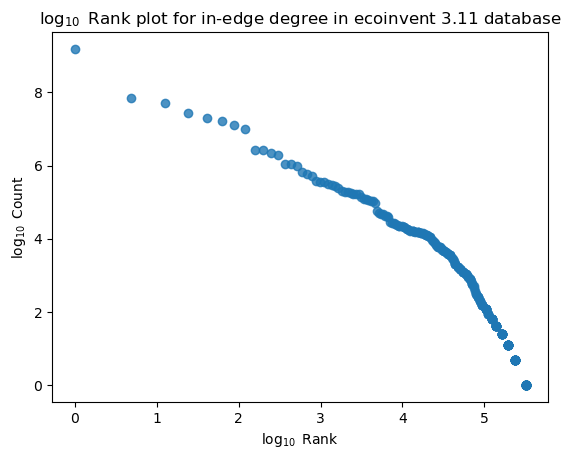

In [36]:
sns.regplot(data=indegree_rank.apply(np.log), y='Count', x='Rank', fit_reg=False)
plt.title(r"$\log_{10}$ Rank plot for in-edge degree in ecoinvent 3.11 database")
plt.xlabel(r"$\log_{10}$ Rank")
plt.ylabel(r"$\log_{10}$ Count")
plt.savefig(f"{root}/Figures/Basic_Viz/network_casestudy/zipf_indegree_plot_3.11.svg", format='svg')

In [37]:
outdegree_rank = counts_to_rank(outdegree_frame)
outdegree_rank.sort_values(by='Count', ascending=False).head(20)

,Degree,Count,Rank
1,2,14670,1.0
661,0,6557,2.0
0,1,3056,3.0
13,3,2191,4.0
541,4,1034,5.0
600,5,547,6.0
515,6,384,7.0
29,7,262,8.0
640,9,217,9.0
572,10,196,10.0


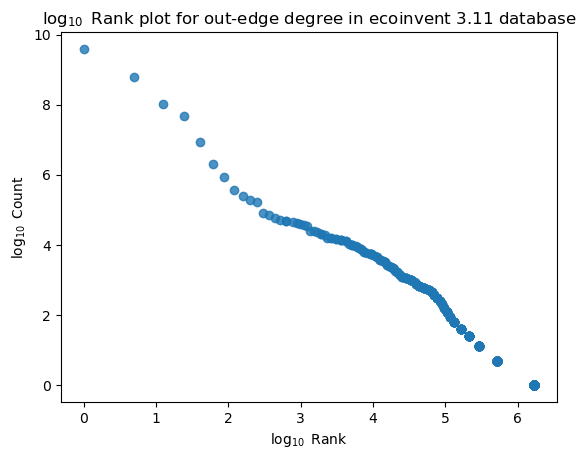

In [38]:
sns.regplot(data=outdegree_rank.apply(np.log), y='Count', x='Rank', fit_reg=False)
plt.title(r"$\log_{10}$ Rank plot for out-edge degree in ecoinvent 3.11 database")
plt.xlabel(r"$\log_{10}$ Rank")
plt.ylabel(r"$\log_{10}$ Count")
plt.savefig(f"{root}/Figures/Basic_Viz/network_casestudy/zipf_outdegree_plot_3.11.svg", format='svg')

In [39]:
max_degree_node = max(G.degree, key=lambda x: x[1])[0]
G.nodes(max_degree_node)

NodeDataView({'4bff710d6157b4750956ba8d1730456b': None, '7f2e5c3fd7efa26314137ba3da3b72f0': None, 'aa7c0137587805454976152c82fb04d0': None, 'cf1d94f16ff735eed8e88931e22b5ce9': None, 'bd7b00a3d5af7ecd4693615d5644cd15': None, 'cde152d6ea2b95e5817989ca0d5ca7d9': None, '7697d27825b9e37160715108feadc3f8': None, 'a35bbe6c66929491706b2ae9d66d4475': None, '3730364e8121f493f949eb861862af04': None, 'b6b5e21485ea9d88ca990a12915f8f83': None, 'd6c2825b8fc242616e4f3af5b065030b': None, '7635d9346d98534af6f6b1f6c87aea63': None, '473d175bbab2f09103ac68f856bc4a04': None, '8f5656cd4c4a03d8506dd04683831b3b': None, 'b7405df1ac78677c3241a0ce90109367': None, 'e7c1a99a5c91ba7372a67024559d7327': None, '8a73c5dfd8b1246214ae1ac7d9dc0151': None, '41683a5a1d0e56eb4b973542182f8e1a': None, '2a8e53fbff53bb50ac43a60fb9168144': None, '07e89f9c8c013b97603cdc652bb867b0': None, '6c039ff4e18a12d6b21062f7137482a5': None, 'a58d6b5215f3ad90010b5d68cc722061': None, 'a4f7c9613cb47c74a386db18964df214': None, '7838c5580db8f0ba028

In [40]:
between_dict = nx.betweenness_centrality(G, k=min(500, len(G)))


In [41]:
freq_df = pd.Series(between_dict).value_counts().reset_index()
freq_df.columns = ['Value', 'Counts']
# freq_df = freq_df[freq_df['Value'] >0 ]
freq_df['rank'] = freq_df['Counts'].rank(method='dense', ascending=False)
freq_df.sort_values(by='Value', ascending=False, inplace=True)
freq_df


,Value,Counts,rank
11695,3.615185e-02,1,32.0
11676,3.208632e-02,1,32.0
11644,2.472361e-02,1,32.0
11543,1.865265e-02,1,32.0
11563,1.523197e-02,1,32.0
...,...,...,...
4393,1.758519e-09,1,32.0
6166,1.721567e-09,1,32.0
1779,1.603913e-09,1,32.0
5234,8.397019e-11,1,32.0


<Axes: xlabel='rank', ylabel='Value'>

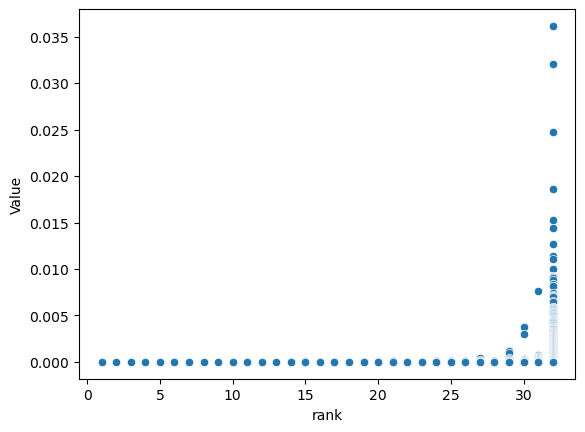

In [42]:
sns.scatterplot(data=freq_df, x='rank', y='Value')

A differential characterization would be useful -- how 